In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from IPython.core.pylabtools import figsize
from unicodedata import category

In [3]:
df = pd.read_csv("Sales Dataset.csv")
pd.set_option('display.max_columns', False)
pd.set_option('display.max_rows', False)

In [4]:
df.head(20)

,Order ID,Amount,Profit,Quantity,Category,Sub-Category,PaymentMode,Order Date,CustomerName,State,City,Year-Month
0,B-26776,9726,1275,5,Electronics,Electronic Games,UPI,2023-06-27,David Padilla,Florida,Miami,2023-06
1,B-26776,9726,1275,5,Electronics,Electronic Games,UPI,2024-12-27,Connor Morgan,Illinois,Chicago,2024-12
2,B-26776,9726,1275,5,Electronics,Electronic Games,UPI,2021-07-25,Robert Stone,New York,Buffalo,2021-07
3,B-26776,4975,1330,14,Electronics,Printers,UPI,2023-06-27,David Padilla,Florida,Miami,2023-06
4,B-26776,4975,1330,14,Electronics,Printers,UPI,2024-12-27,Connor Morgan,Illinois,Chicago,2024-12
5,B-26776,4975,1330,14,Electronics,Printers,UPI,2021-07-25,Robert Stone,New York,Buffalo,2021-07
6,B-26942,1525,185,12,Office Supplies,Pens,Debit Card,2024-05-11,John Fields,Florida,Orlando,2024-05
7,B-26942,1525,185,12,Office Supplies,Pens,Debit Card,2021-10-09,Clayton Smith,Florida,Miami,2021-10
8,B-26640,883,117,10,Electronics,Laptops,EMI,2022-11-18,Richard Kelley,California,Los Angeles,2022-11
...,...,...,...,...,...,...,...,...,...,...,...,...


In [45]:
df[['Order Date', 'Year-Month']] = df[['Order Date', 'Year-Month']].apply(pd.to_datetime)

# Quais Sub-Category vendem mais?

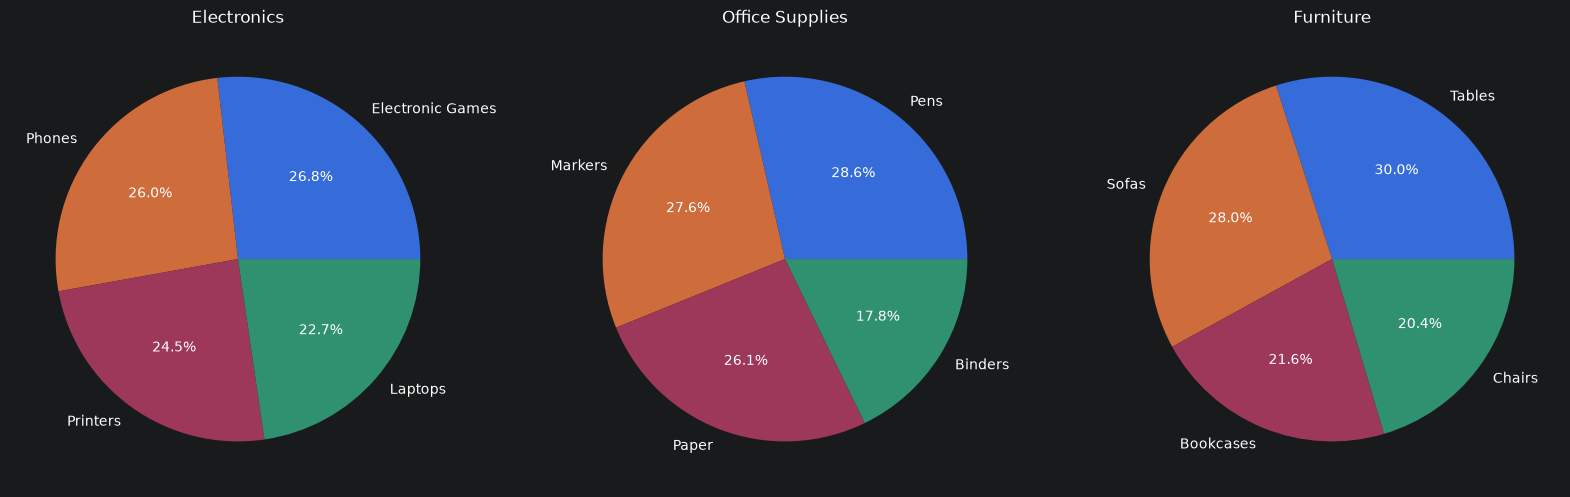

In [52]:
productCategory = df["Category"].unique()
fig, axes = plt.subplots(1, len(productCategory), figsize=(20, 10))

for ax, category in zip(axes, productCategory):

    subCategory = df[df['Category'] == category]
    subCategory = subCategory.value_counts('Sub-Category').reset_index()
    subCategory.columns = ['Product', 'Count']

    ax.pie(
        subCategory['Count'],
        labels=subCategory['Product'],
        autopct='%1.1f%%')

    ax.set_title(f'{category}')

## Qual lucro de cada estado?

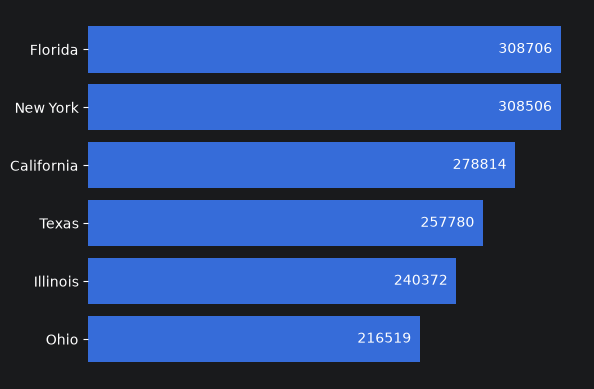

In [91]:
stateVendas = df[['State', 'Profit']].groupby('State').agg("sum").sort_values(by="Profit").reset_index()
bars = plt.barh(stateVendas['State'], stateVendas['Profit'])

plt.bar_label(bars, fmt='%.0f', padding=-45)
plt.xticks([])

ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(False)

plt.show()

## Ao decorrer do tempo as vendas forma crescendo?

Text(0.5, 1.0, 'Vendas nos anos de 2020 ate 2025')

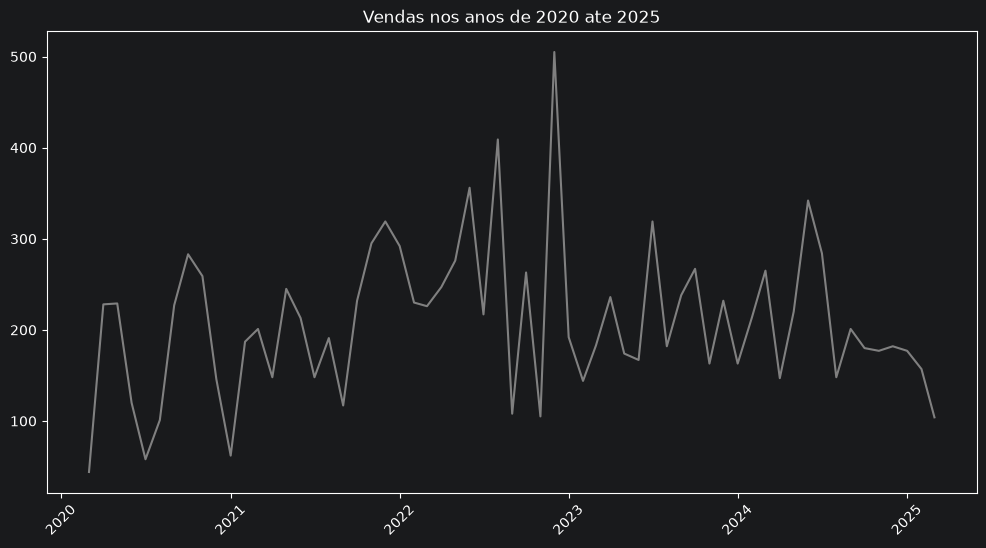

In [167]:
import matplotlib.dates as mdates
plt.figure(figsize=(12, 6))

vendasTempo = (df[['Year-Month', 'Quantity']]
               .groupby('Year-Month')
               .agg("sum")
               .sort_values(by="Year-Month")
               .reset_index())

plt.plot(vendasTempo['Year-Month'],
         vendasTempo['Quantity'],
         label='Line 1',
         color='gray')

# ax = plt.gca()
# ax.xaxis.set_major_locator(mdates.MonthLocator(interval=5))
# ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

plt.xticks(rotation=45)
plt.xlabel('')
plt.ylabel('')
plt.title("Vendas nos anos de 2020 ate 2025")

## Quais clientes mais compraram e o lucro que deram?


Text(0.5, 1.0, 'Lucro dado a empresa')

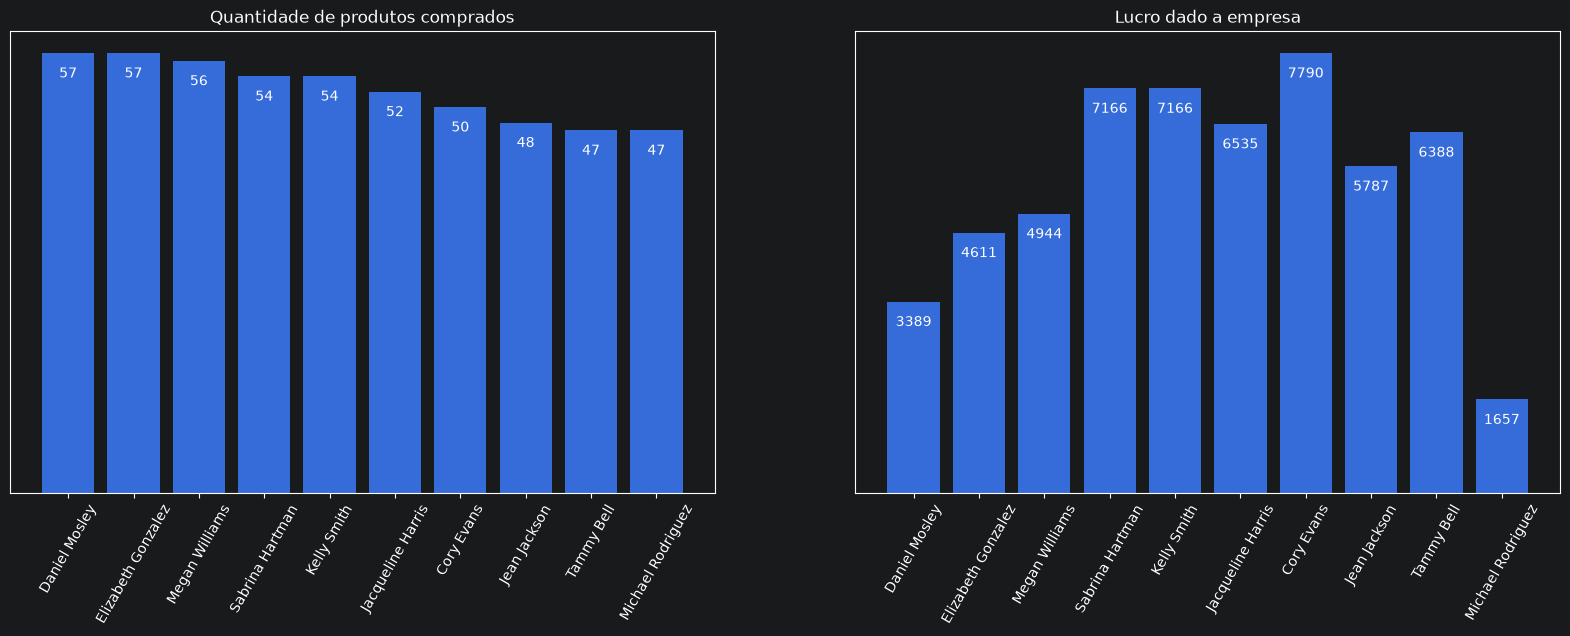

In [166]:
fig, axes = plt.subplots(1, 2, figsize=(20, 6))

clientesCompras = (df[['CustomerName','Quantity', 'Profit']]
    .groupby('CustomerName')
    .agg("sum")
    .sort_values(by="Quantity",
    ascending=False)
    .reset_index()
    .iloc[:10])

# Quantidade comprada
bars = axes[0].bar(clientesCompras['CustomerName'], clientesCompras['Quantity'])
axes[0].bar_label(bars, fmt='%.0f', padding=-20)
axes[0].set_yticks([])
axes[0].tick_params(axis='x', rotation=60)
axes[0].set_title("Quantidade de produtos comprados")


# Lucro que deram
bars2 = axes[1].bar(clientesCompras['CustomerName'], clientesCompras['Profit'])
axes[1].bar_label(bars2, fmt='%.0f', padding=-20)
axes[1].set_yticks([])
axes[1].tick_params(axis='x', rotation=60)
axes[1].set_title("Lucro dado a empresa")


## Qual metodo de pagamento mais usado?

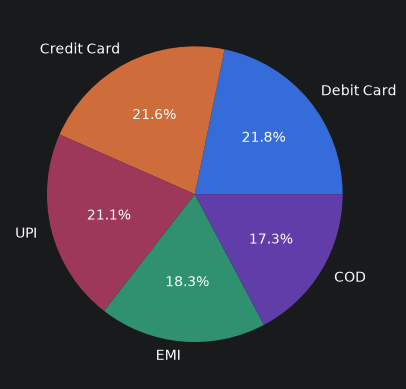

In [188]:
payMode = df['PaymentMode'].value_counts().reset_index()
payMode.columns = ['PaymentMode', 'Count']
plt.pie(payMode['Count'],
                labels=payMode['PaymentMode'],
                 autopct='%1.1f%%')